In [17]:
import matplotlib.pyplot as plt
import numpy as np
import sys, os

from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent))

import pandas as pd
from general.dat_helper import group_by_mean
from glob import glob

print(os.getcwd())

from general.plot_settings import paper_settings, generate_plt_styles, colors
plt.rcParams.update(paper_settings)
colors = colors[0:]
# colors = ['blue', 'red']
styles = generate_plt_styles(colors=colors)
plt.rcParams['lines.markersize'] = 4
plt.rcParams['legend.fontsize'] = 7

c:\Users\coldatoms\Documents\cjdGitHub\ChiPyLab\examples


In [6]:
files = ["2022-08-18_C_LAT1_AM.dat"]

data_folder = os.path.join("..", "data", "aom_efficiency")
files = glob(os.path.join(data_folder, '*'))

dfs = []
for file in files:
    dfs.append(pd.read_table(file, delimiter=',')) # making dataframe of chosen data

print(files)
print(dfs[0].columns)
print(dfs[0])

['..\\data\\aom_efficiency\\HF_FM_power.txt', '..\\data\\aom_efficiency\\K_FM_power.txt']
Index(['FM', 'Power'], dtype='object')
     FM   Power
0   176    0.83
1   170    5.27
2   164   14.10
3   158   41.90
4   154  109.20
5   150  136.00
6   146  149.00
7   142  192.00
8   140  202.00
9   138  207.00
10  136  206.00
11  134  202.00
12  132  195.00
13  130  192.00
14  128  191.00
15  126  185.00
16  124  179.00
17  122  169.00
18  118  151.00
19  114  136.00
20  110  119.00
21  102   88.10
22   94   63.50
23   86   40.00
24   78   22.10
25   70   22.50
26   62    4.62
27   54    2.86
28   46    0.81


250 G max freq is HF = 153, K = 93
230 G max freq is HF = 142, K = 96
209 G max freq is HF = 140, K = 109
202.14 G max freq is HF = 138, K = 112
140 G max freq is HF = 101, K = 118


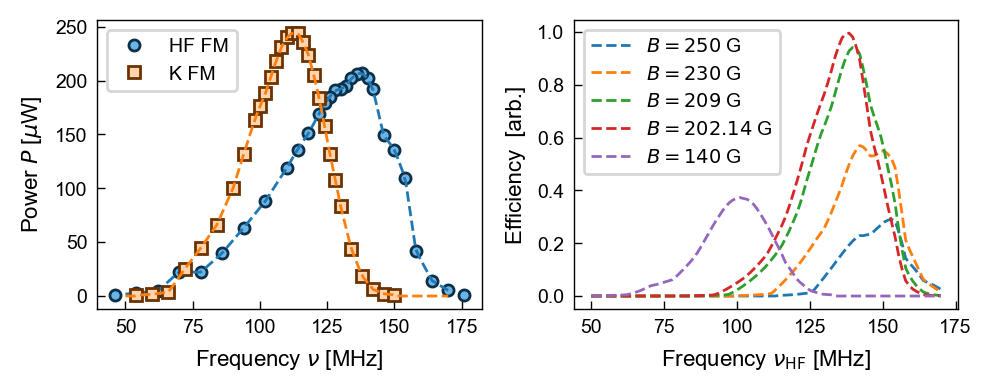

In [28]:
from scipy.interpolate import interp1d

scan_name = 'FM'
y_name = 'Power'

fig, axs = plt.subplots(1, 2, figsize=(5,2))

# --- Raw FM data ---
ax = axs[0]

xmin = 50
xmax = 170
xs = np.linspace(xmin, xmax, 100)

# HF FM
i = 0
df = dfs[i]
xlabel = r'Frequency $\nu$ [MHz]'
ylabel = r'Power $P$ [$\mu$W]'
ax.set(xlabel=xlabel, ylabel=ylabel)

x = df[scan_name]
sty, color = (styles[i], colors[i])
y = df[y_name]
ax.plot(x, y, **sty, label=r'HF FM')

HF_interp = interp1d(x, y, kind='linear', bounds_error=False, fill_value=0)
ys = HF_interp(xs)
ax.plot(xs, ys, color=color, ls='--')

# K FM
i = 1
df = dfs[i]
xlabel = r'Frequency $\nu$ [MHz]'
ylabel = r'Power $P$ [$\mu$W]'
ax.set(xlabel=xlabel, ylabel=ylabel)

x = df[scan_name]
sty, color = (styles[i], colors[i])
y = df[y_name]
ax.plot(x, y, **sty, label=r'K FM')


K_interp = interp1d(x, y, kind='linear', bounds_error=False, fill_value=0)
ys = K_interp(xs)
ax.plot(xs, ys, color=color, ls='--')

ax.legend()


# --- Efficiency at each B field ---

def req_KFM(nu_HF, field):
    return nu_HF + 0.5 * (-62 - 1.4 * (field - 209))

def efficiency(nu_HF, field):
    nu_K = req_KFM(nu_HF, field)
    K_max = np.max(K_interp(xs))
    HF_max = np.max(HF_interp(xs))
    return HF_interp(nu_HF) * K_interp(nu_K) / (HF_max * K_max)


ax = axs[1]


xlabel = r'Frequency $\nu_\mathrm{HF}$ [MHz]'
ylabel = r'Efficiency  [arb.]'
ax.set(xlabel=xlabel, ylabel=ylabel)

x = dfs[0][scan_name]

# 250 G
i = 0
B = 250
sty, color = (styles[i], colors[i])
ys = efficiency(xs, B)
best_x = xs[np.argmax(ys)]
print(f"{B} G max freq is HF = {best_x:.0f}, K = {req_KFM(best_x, B):.0f}")
ax.plot(xs, ys, color=color, ls='--', label=r'$B = 250$ G')


# 230 G
i = 1
B = 230
sty, color = (styles[i], colors[i])
ys = efficiency(xs, B)
best_x = xs[np.argmax(ys)]
print(f"{B} G max freq is HF = {best_x:.0f}, K = {req_KFM(best_x, B):.0f}")
ax.plot(xs, ys, color=color, ls='--', label=r'$B = 230$ G')


# 209 G
i = 2
B = 209
sty, color = (styles[i], colors[i])

ys = efficiency(xs, B)
best_x = xs[np.argmax(ys)]
print(f"{B} G max freq is HF = {best_x:.0f}, K = {req_KFM(best_x, B):.0f}")
ax.plot(xs, ys, color=color, ls='--', label=r'$B = 209$ G')

# 202.14 G
i = 3
B = 202.14
sty, color = (styles[i], colors[i])
ys = efficiency(xs, B)
best_x = xs[np.argmax(ys)]
print(f"{B} G max freq is HF = {best_x:.0f}, K = {req_KFM(best_x, B):.0f}")
ax.plot(xs, ys, color=color, ls='--', label=r'$B = 202.14$ G')

# 140 G
i = 4
B = 140
sty, color = (styles[i], colors[i])
ys = efficiency(xs, B)
best_x = xs[np.argmax(ys)]
print(f"{B} G max freq is HF = {best_x:.0f}, K = {req_KFM(best_x, B):.0f}")
ax.plot(xs, ys, color=color, ls='--', label=r'$B = 140$ G')

ax.legend()


fig.tight_layout()
# fig.savefig("outputs/LAT1_AM_spectroscopy.pdf")
plt.show()